# PV + BESS + Flexible EV Charging LP

Goal:

Optimize the daily operation of a system composed of:

- Building electrical load
- Photovoltaic generation
- Battery Energy Storage System (BESS)
- Flexible EV charging
- Electricity prices

The objective is to minimize electricity cost while satisfying building demand, EV charging requirements and battery constraints.

This notebook integrates all previous notebooks into a single optimization problem.

In [ ]:
# ==========================================================
# Imports
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.optimize import linprog              

In [3]:
# ==========================================================
# Load yearly datasets
# ==========================================================

ev = pd.read_csv("../data/raw/ev_sessions.csv")

load_mat = loadmat("../data/raw/load_yearly.mat")
pv_mat = loadmat("../data/raw/PV_production_yearly.mat")
price_mat = loadmat("../data/raw/prices_yearly.mat")

load_year = load_mat["load_all_year"].flatten()
pv_factor = pv_mat["zeta_PV"].flatten()
price_year = price_mat["prices_all_year"].flatten()

print("EV sessions:", len(ev))
print("Load shape :", load_year.shape)
print("PV shape   :", pv_factor.shape)
print("Price shape:", price_year.shape)

EV sessions: 8530
Load shape : (8760,)
PV shape   : (8760,)
Price shape: (8760,)


In [4]:
# ==========================================================
# Representative day
#
# We start with the high-demand scenario.
#
# Later we will repeat the same optimization for:
# - Day 106 (low)
# - Day 20  (medium)
# - Day 95  (high)
# ==========================================================

DAY = 95

hours = np.arange(24)

load_day = load_year[
    (DAY - 1) * 24 : DAY * 24
]

price_day = price_year[
    (DAY - 1) * 24 : DAY * 24
]

ev_day = ev[
    ev["day"] == DAY
].copy()

print("Selected day:", DAY)
print("EV sessions:", len(ev_day))
print("EV energy:", ev_day["energy_kwh"].sum())

Selected day: 95
EV sessions: 35
EV energy: 509.0


Define PV and Battery 

In [5]:
# ==========================================================
# PV and battery parameters
#
# Same values used previously.
#
# These will become optimization variables later.
# ==========================================================

S_PV = 300

pv_day = (
    S_PV
    * pv_factor[
        (DAY - 1) * 24 : DAY * 24
    ]
)

E_BESS = 200

SOC_min = 0.10 * E_BESS
SOC_max = 0.90 * E_BESS

P_BESS_max = 50

eta_ch = 0.95
eta_dis = 0.95

SOC_initial = 100

print("PV size [kWp]:", S_PV)
print("BESS capacity [kWh]:", E_BESS)

PV size [kWp]: 300
BESS capacity [kWh]: 200


remove the zero-energy EVs


In [6]:
# ==========================================================
# Remove EV sessions with zero required energy
#
# Some vehicles may appear in the dataset but require
# no charging energy.
#
# They do not need decision variables in the optimization.
# ==========================================================

ev_opt = ev_day[
    ev_day["energy_kwh"] > 0
].copy()

ev_opt = ev_opt.reset_index(drop=True)

n_ev = len(ev_opt)

print("EVs included in optimization:", n_ev)
print("Total EV energy [kWh]:", ev_opt["energy_kwh"].sum())

EVs included in optimization: 34
Total EV energy [kWh]: 509.0


Degine LP dimensions

In [7]:
# ==========================================================
# LP DIMENSIONS
# ==========================================================

N = 24
dt = 1.0

P_EV_max = 7.0  # max charging power per EV [kW]

print("Number of hours:", N)
print("Number of EVs:", n_ev)

Number of hours: 24
Number of EVs: 34


Decisision variables indexing 

In [8]:
# ==========================================================
# DECISION VARIABLE VECTOR
# ==========================================================
#
# x contains:
#
# 1) EV charging powers:
#    P_EV[i,h]
#
# 2) BESS charging power:
#    P_BESS_ch[h]
#
# 3) BESS discharging power:
#    P_BESS_dch[h]
#
# 4) Battery state of charge:
#    SOC[h], h = 0,...,24
#
# 5) Grid import:
#    P_grid_import[h]
#
# 6) Grid export:
#    P_grid_export[h]
#
# ==========================================================

idx_ev_start = 0
idx_bess_ch_start = idx_ev_start + n_ev * N
idx_bess_dch_start = idx_bess_ch_start + N
idx_soc_start = idx_bess_dch_start + N
idx_grid_import_start = idx_soc_start + (N + 1)
idx_grid_export_start = idx_grid_import_start + N

n_vars = idx_grid_export_start + N

print("Number of optimization variables:", n_vars)

Number of optimization variables: 937


# Objective Functions

In [9]:
# ==========================================================
# OBJECTIVE FUNCTION
# ==========================================================
#
# Minimize:
#
# Σ price[h] * P_grid_import[h]
#
# Grid export is currently assumed to have no revenue.
#
# Later we can add feed-in tariffs if desired.
# ==========================================================

c = np.zeros(n_vars)

for h in range(N):

    idx = idx_grid_import_start + h

    c[idx] = price_day[h]

print("Objective vector shape:", c.shape)

Objective vector shape: (937,)


34 EVs
24 BESS charge
24 BESS discharge
25 SOC
24 import
24 export

Power balance constraints

In [10]:
# ==========================================================
# POWER BALANCE
# ==========================================================
#
# For every hour:
#
# PV + Grid_import + BESS_discharge
#
# =
#
# Load + EV_charging + BESS_charge + Grid_export
#
# ==========================================================

A_eq = []
b_eq = []

for h in range(N):

    row = np.zeros(n_vars)

    # EV charging terms
    for i in range(n_ev):

        ev_idx = idx_ev_start + i * N + h

        row[ev_idx] = 1.0

    # BESS charge
    row[idx_bess_ch_start + h] = 1.0

    # BESS discharge
    row[idx_bess_dch_start + h] = -1.0

    # Grid import
    row[idx_grid_import_start + h] = -1.0

    # Grid export
    row[idx_grid_export_start + h] = 1.0

    rhs = pv_day[h] - load_day[h]

    A_eq.append(row)
    b_eq.append(rhs)

print("Power balance equations:", len(A_eq))

Power balance equations: 24


EV energy constraints

In [11]:
# ==========================================================
# EV ENERGY REQUIREMENTS
# ==========================================================
#
# Each EV must leave with the requested energy.
#
# Σ P_EV[i,h]
#
# =
#
# Required energy
#
# ==========================================================

for i in range(n_ev):

    row = np.zeros(n_vars)

    for h in range(N):

        ev_idx = idx_ev_start + i * N + h

        row[ev_idx] = dt

    A_eq.append(row)

    b_eq.append(
        ev_opt.loc[i, "energy_kwh"]
    )

print("Total equations so far:", len(A_eq))

Total equations so far: 58


# 24 + 34 = 58 equations

SOC dynamics

In [12]:
# ==========================================================
# BATTERY SOC DYNAMICS
# ==========================================================
#
# SOC[h+1]
#
# =
#
# SOC[h]
# + eta_ch * P_charge[h]
# - P_discharge[h] / eta_dis
#
# This equation links all hours together.
#
# ==========================================================

for h in range(N):

    row = np.zeros(n_vars)

    # SOC(h+1)
    row[idx_soc_start + h + 1] = 1.0

    # SOC(h)
    row[idx_soc_start + h] = -1.0

    # charge
    row[idx_bess_ch_start + h] = -eta_ch

    # discharge
    row[idx_bess_dch_start + h] = 1.0 / eta_dis

    A_eq.append(row)

    b_eq.append(0)

print("Total equations after SOC:", len(A_eq))

Total equations after SOC: 82


Initial SOC

In [13]:
# ==========================================================
# INITIAL BATTERY ENERGY
# ==========================================================
#
# Fix SOC(0)
#
# ==========================================================

row = np.zeros(n_vars)

row[idx_soc_start] = 1.0

A_eq.append(row)

b_eq.append(SOC_initial)

print("Total equations after initial SOC:", len(A_eq))

Total equations after initial SOC: 83


Convert Matrices

In [14]:
# ==========================================================
# Convert constraints to numpy arrays
# ==========================================================

A_eq = np.array(A_eq)

b_eq = np.array(b_eq)

print("A_eq shape:", A_eq.shape)
print("b_eq shape:", b_eq.shape)

A_eq shape: (83, 937)
b_eq shape: (83,)


Variable Bounds

In [15]:
# ==========================================================
# VARIABLE BOUNDS
# ==========================================================
#
# EV charging:
# - allowed only during connection window
# - limited by charger power
#
# BESS:
# - charge/discharge power limited
# - SOC limited between SOC_min and SOC_max
#
# Grid:
# - import/export non-negative
# ==========================================================

bounds = []

# ----------------------------------------------------------
# 1) EV charging bounds
# ----------------------------------------------------------

for i in range(n_ev):

    connection_minute = ev_opt.loc[i, "connection_minute"]
    disconnection_minute = ev_opt.loc[i, "disconnection_minute"]

    for h in range(N):

        hour_start = h * 60
        hour_end = (h + 1) * 60

        overlap_min = max(
            0,
            min(disconnection_minute, hour_end)
            - max(connection_minute, hour_start)
        )

        if overlap_min > 0:
            bounds.append((0, P_EV_max))
        else:
            bounds.append((0, 0))


# ----------------------------------------------------------
# 2) BESS charge bounds
# ----------------------------------------------------------

for h in range(N):
    bounds.append((0, P_BESS_max))


# ----------------------------------------------------------
# 3) BESS discharge bounds
# ----------------------------------------------------------

for h in range(N):
    bounds.append((0, P_BESS_max))


# ----------------------------------------------------------
# 4) SOC bounds
# ----------------------------------------------------------

for h in range(N + 1):
    bounds.append((SOC_min, SOC_max))


# ----------------------------------------------------------
# 5) Grid import bounds
# ----------------------------------------------------------

for h in range(N):
    bounds.append((0, None))


# ----------------------------------------------------------
# 6) Grid export bounds
# ----------------------------------------------------------

for h in range(N):
    bounds.append((0, None))


print("Number of bounds:", len(bounds))
print("Number of variables:", n_vars)

Number of bounds: 937
Number of variables: 937


Solve Integrated LP

In [16]:
# ==========================================================
# SOLVE INTEGRATED LP
# ==========================================================

result = linprog(
    c=c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

print("Solver success:", result.success)
print("Solver message:", result.message)
print("Optimal cost [EUR]:", result.fun)

Solver success: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Optimal cost [EUR]: 16.83130167838781


Extract Result 

In [17]:
# ==========================================================
# EXTRACT OPTIMAL SOLUTION
# ==========================================================
#
# Recover all physical variables from the LP solution vector.
#
# ==========================================================

x_opt = result.x

# ----------------------------------------------------------
# EV charging
# ----------------------------------------------------------

P_EV_opt = x_opt[
    idx_ev_start : idx_bess_ch_start
].reshape(n_ev, N)

ev_profile_opt = P_EV_opt.sum(axis=0)

# ----------------------------------------------------------
# BESS charge
# ----------------------------------------------------------

P_ch_opt = x_opt[
    idx_bess_ch_start : idx_bess_dch_start
]

# ----------------------------------------------------------
# BESS discharge
# ----------------------------------------------------------

P_dch_opt = x_opt[
    idx_bess_dch_start : idx_soc_start
]

# ----------------------------------------------------------
# SOC
# ----------------------------------------------------------

SOC_opt = x_opt[
    idx_soc_start : idx_grid_import_start
]

# ----------------------------------------------------------
# Grid import
# ----------------------------------------------------------

P_grid_import_opt = x_opt[
    idx_grid_import_start : idx_grid_export_start
]

# ----------------------------------------------------------
# Grid export
# ----------------------------------------------------------

P_grid_export_opt = x_opt[
    idx_grid_export_start :
]

print("EV energy delivered [kWh]:", ev_profile_opt.sum())
print("Maximum EV charging power [kW]:", ev_profile_opt.max())
print("Maximum SOC [kWh]:", SOC_opt.max())
print("Maximum grid import [kW]:", P_grid_import_opt.max())

EV energy delivered [kWh]: 509.0
Maximum EV charging power [kW]: 120.063807706
Maximum SOC [kWh]: 180.0
Maximum grid import [kW]: 50.097780323500004


Main Operational Plot 

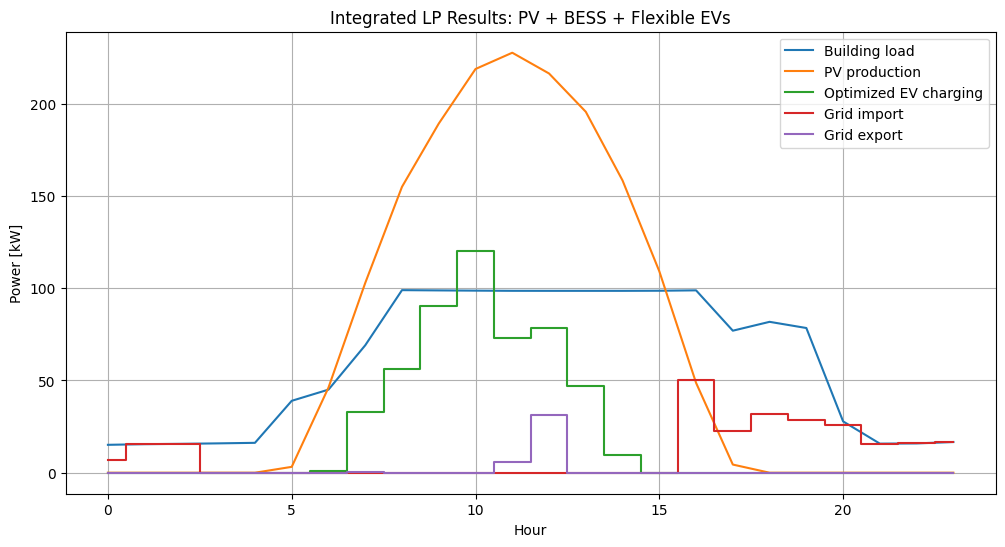

In [18]:
# ==========================================================
# MAIN OPERATIONAL RESULTS
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(hours, load_day,
         label="Building load")

plt.plot(hours, pv_day,
         label="PV production")

plt.step(hours,
         ev_profile_opt,
         where="mid",
         label="Optimized EV charging")

plt.step(hours,
         P_grid_import_opt,
         where="mid",
         label="Grid import")

plt.step(hours,
         P_grid_export_opt,
         where="mid",
         label="Grid export")

plt.xlabel("Hour")
plt.ylabel("Power [kW]")

plt.title(
    "Integrated LP Results: PV + BESS + Flexible EVs"
)

plt.grid()
plt.legend()

plt.show()

Battery Operation

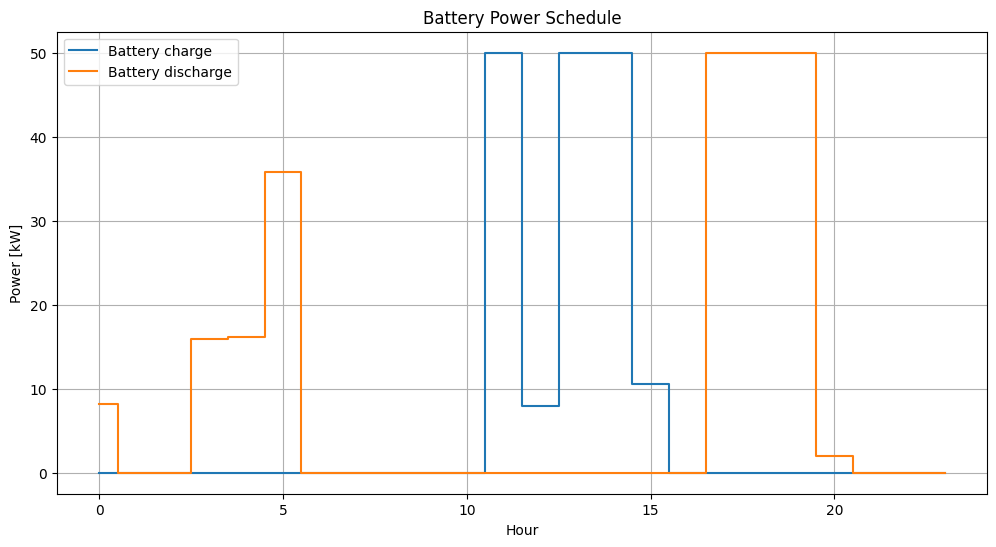

In [19]:
# ==========================================================
# BATTERY OPERATION
# ==========================================================

plt.figure(figsize=(12,6))

plt.step(hours,
         P_ch_opt,
         where="mid",
         label="Battery charge")

plt.step(hours,
         P_dch_opt,
         where="mid",
         label="Battery discharge")

plt.xlabel("Hour")
plt.ylabel("Power [kW]")

plt.title("Battery Power Schedule")

plt.grid()
plt.legend()

plt.show()

SOC

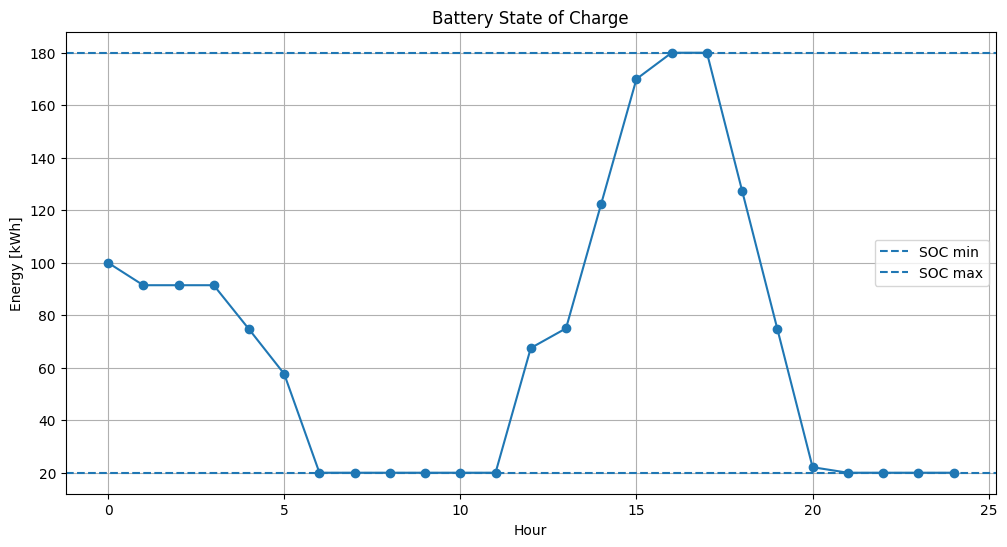

In [20]:
# ==========================================================
# BATTERY STATE OF CHARGE
# ==========================================================

plt.figure(figsize=(12,6))

plt.plot(
    np.arange(N+1),
    SOC_opt,
    marker="o"
)

plt.axhline(
    SOC_min,
    linestyle="--",
    label="SOC min"
)

plt.axhline(
    SOC_max,
    linestyle="--",
    label="SOC max"
)

plt.xlabel("Hour")
plt.ylabel("Energy [kWh]")

plt.title("Battery State of Charge")

plt.grid()
plt.legend()

plt.show()